Imporet library


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.cluster as cluster

import dataset

In [12]:
df = pd.read_csv('Mall_Customers.csv')
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


Map 'Gender' to numerical values

In [13]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

Correaliton

In [14]:

correlation_matrix = df.corr()

Rename columns for convenience

In [15]:
df.rename(columns={
'Age': 'age',
'Gender': 'gender',
'CustomerID': 'id',
'Annual Income (k$)': 'income',
'Spending Score (1-100)': 'score'
}, inplace=True)

In [16]:
import sklearn.cluster as cluster


kmeans = cluster.KMeans(n_clusters = 5)
kmeans = kmeans.fit(df[['income','score']])


kmeans.cluster_centers_

array([[88.2       , 17.11428571],
       [25.72727273, 79.36363636],
       [86.53846154, 82.12820513],
       [55.2962963 , 49.51851852],
       [26.30434783, 20.91304348]])

apply KMeans clustering

In [17]:
kmeans = cluster.KMeans(n_clusters=5)
kmeans = kmeans.fit(df[['income', 'score']])

cluster


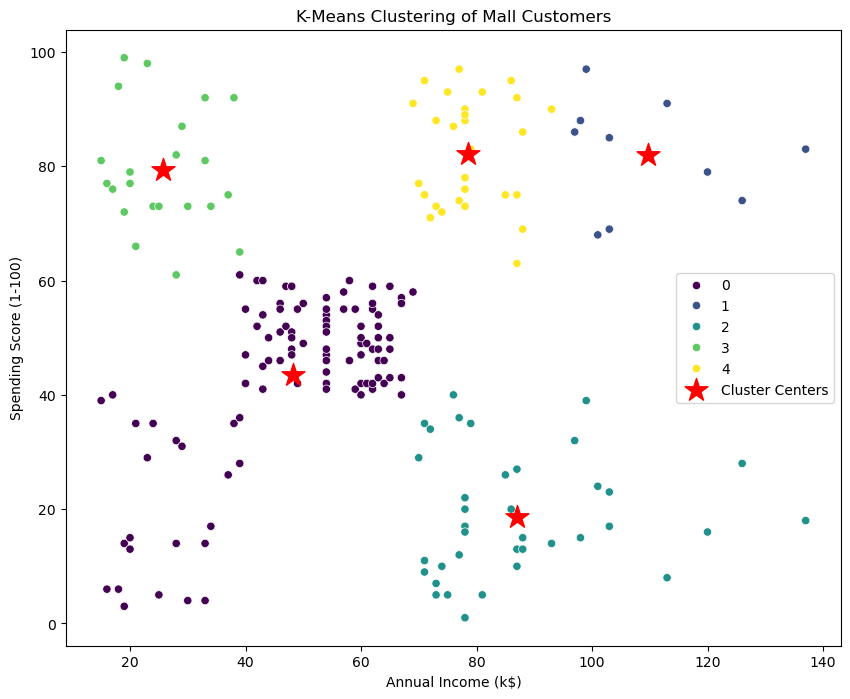

In [18]:
# Cluster centers
cluster_centers = kmeans.cluster_centers_

# Assign clusters to data points
df['cluster'] = kmeans.labels_

# Visualize clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='income', y='score', hue='cluster', palette='viridis')
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], s=300, c='red', marker='*', label='Cluster Centers')
plt.title('K-Means Clustering of Mall Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()



elbow method

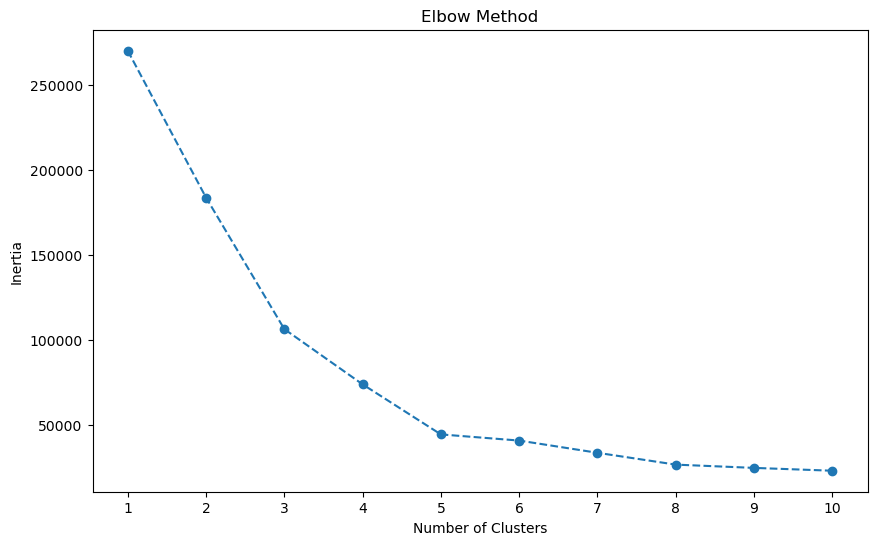

In [19]:
inertia = []
for k in range(1, 11):
    kmeans = cluster.KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df[['income', 'score']])
    inertia.append(kmeans.inertia_)

# Plotting the Elbow curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.show()

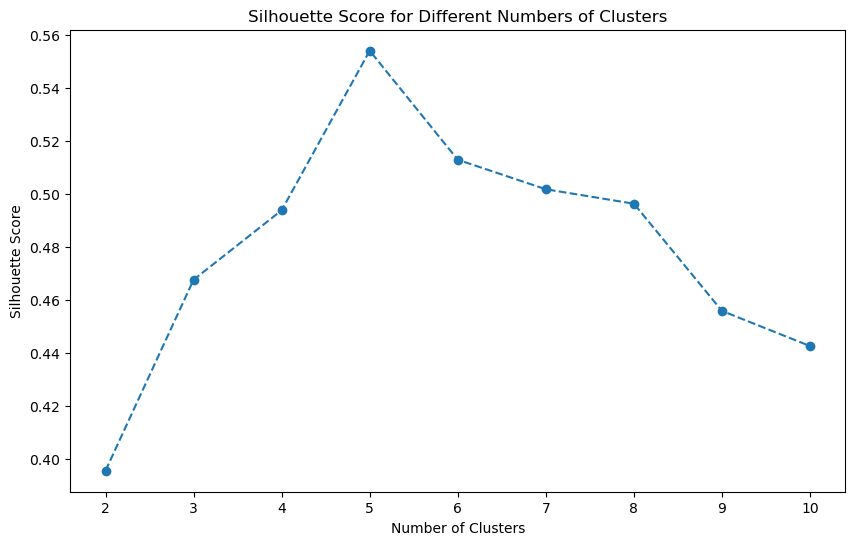

In [20]:
from sklearn.metrics import silhouette_score

# Apply KMeans clustering
k_values = range(2, 11)  # Trying different number of clusters
silhouette_scores = []

for k in k_values:
    kmeans = cluster.KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(df[['income', 'score']])
    silhouette_avg = silhouette_score(df[['income', 'score']], cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plotting Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Score for Different Numbers of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.show()